# Workshop 3: Convolutional Neural Networks for MNIST and CIFAR Classification

---

In this lab, we will implement and train Convolutional Neural Networks (CNNs)
for image classification tasks using the MNIST and CIFAR datasets.

By the end of this workshop, you will:
- Understand convolution and pooling layers
- Train a CNN using TensorFlow/Keras
- Evaluate classification performance
- Visualize training accuracy


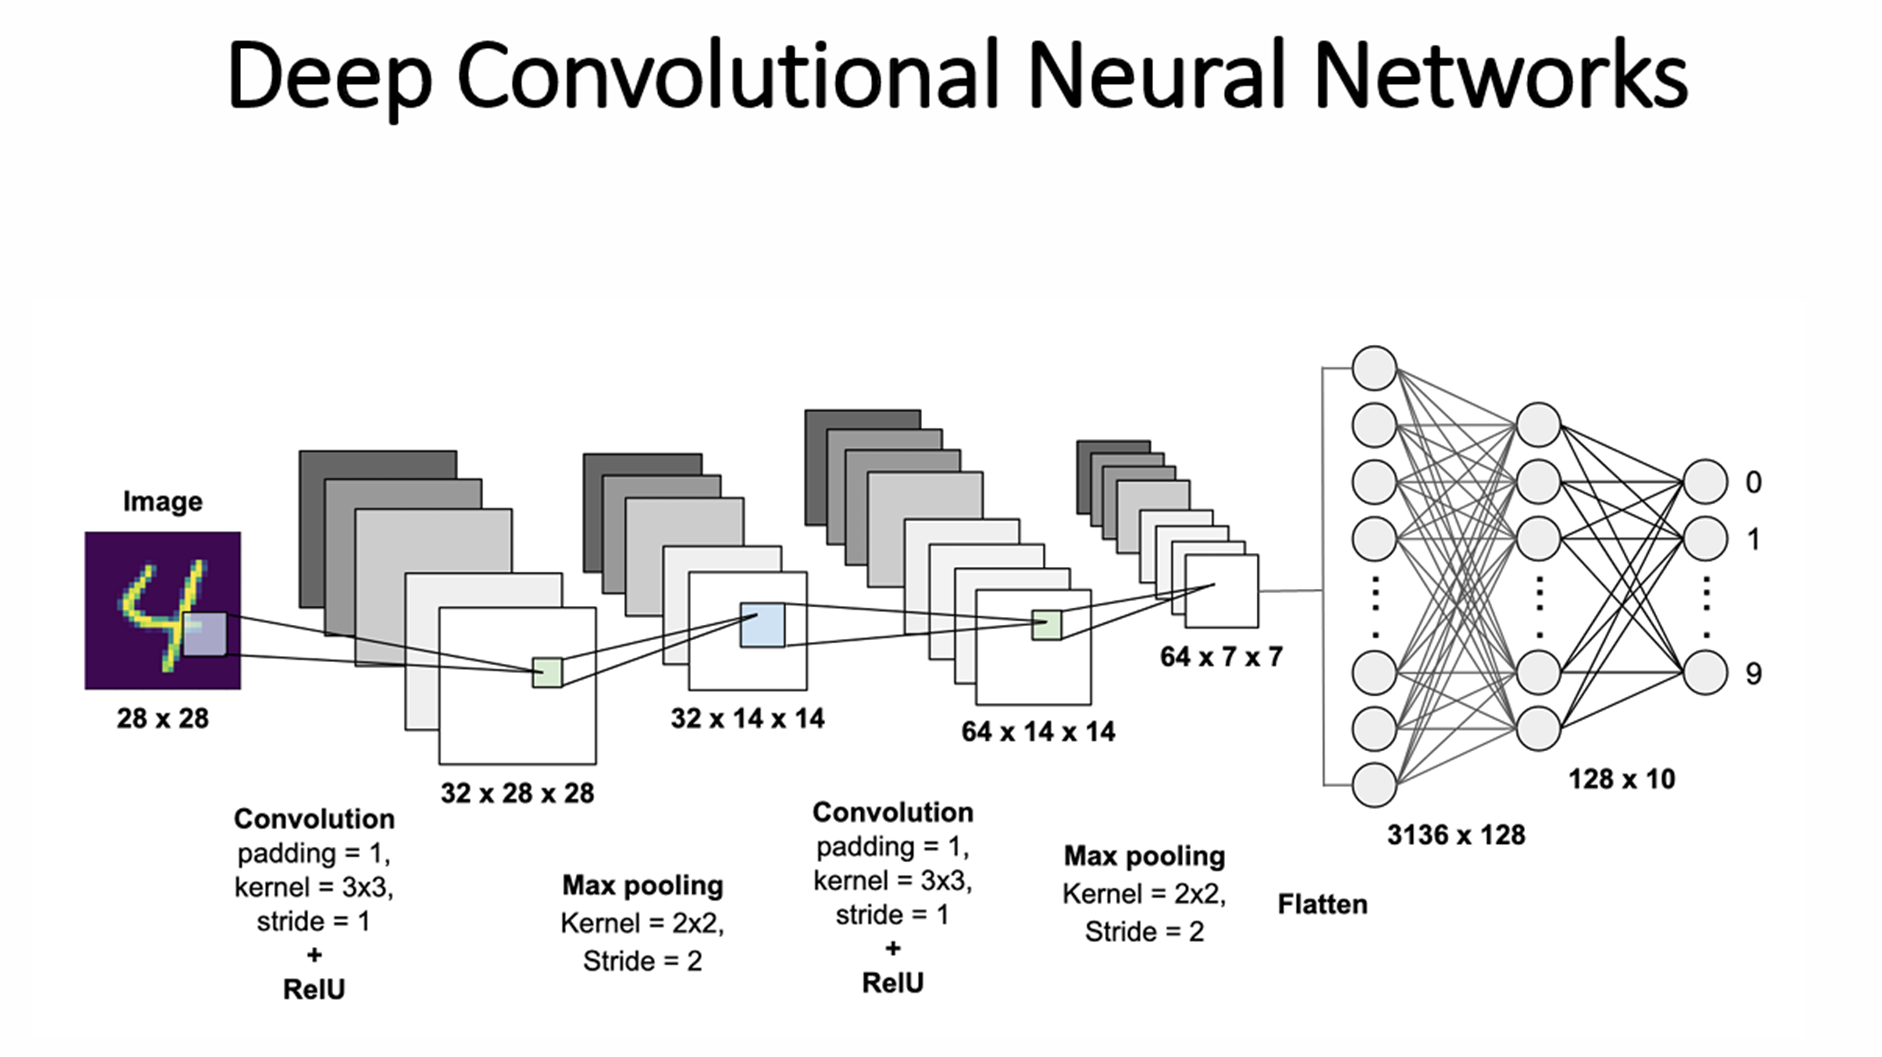

# Import packages

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split


# Load the CIFAR-10 dataset, split into train and test sets, and normalize the pixel values


In [ ]:
num_classes = 10
input_shape = (32, 32, 3)

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have correct shape
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (50000, 32, 32, 3, 1)
50000 train samples
10000 test samples


# View CIFAR-10 Samples

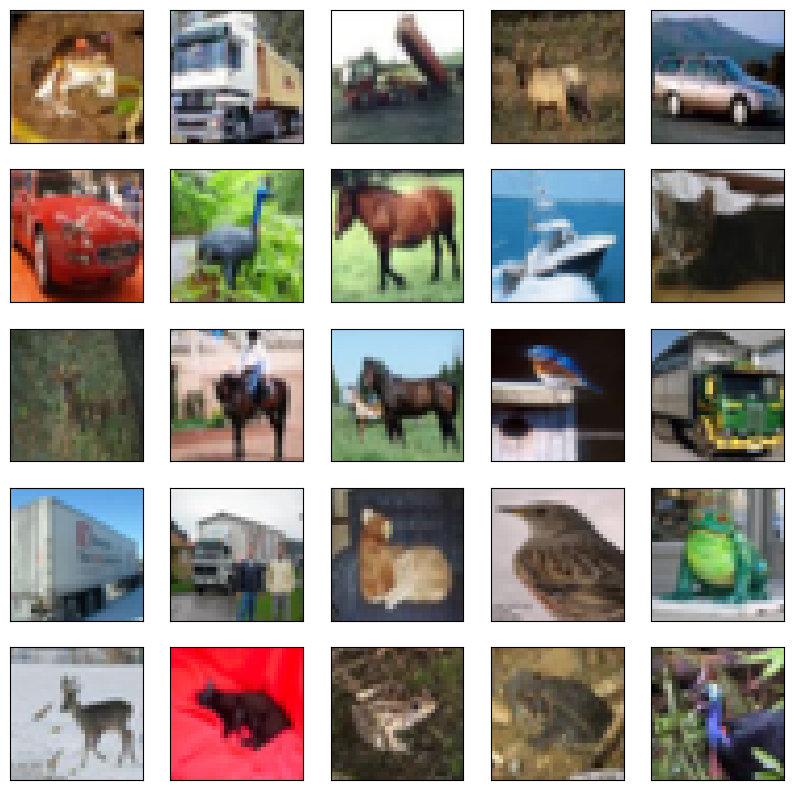

In [ ]:


plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_train[i,:,:,:]))
plt.show()

# One-hot-encoding

In [ ]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# Define the CNN model
We now construct a convolutional neural network consisting of:
- Convolution layers for feature extraction
- Pooling layers for spatial downsampling
- Fully connected layers for classification


In [ ]:
#Arc 1:
model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same",kernel_regularizer=regularizers.l2(0.0005)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same",kernel_regularizer=regularizers.l2(0.0005)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),

    ]
)
model.summary()


#***************************************************
#Arch 2:
# model = tf.keras.Sequential(
#     [
#         tf.keras.Input(shape=input_shape),
#         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#         layers.MaxPooling2D(pool_size=(2, 2)),
#         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#         layers.MaxPooling2D(pool_size=(2, 2)),
#         layers.Flatten(),
#         layers.Dense(10, activation="softmax"),

#     ]
# )
# model.summary()

#***************************************************
# Arch 3:
# model = tf.keras.Sequential(
#     [
#         tf.keras.Input(shape=input_shape),
#         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#         layers.MaxPooling2D(pool_size=(2, 2)),
#         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#         layers.MaxPooling2D(pool_size=(2, 2)),
#         layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
#         layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'),
#         layers.MaxPooling2D(pool_size=(2, 2)),
#         layers.Flatten(),
#         #layers.Dropout(0.5),
#         layers.Dense(128, activation="relu"),
#         layers.Dense(10, activation="softmax"),

#     ]
# )
# model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │          81,930 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 92,074 (359.66 KB)

 Trainable params: 92,074 (359.66 KB)

 Non-trainable params: 0 (0.00 B)

# Configure the model

In [ ]:
from keras.optimizers import Adam

# Available optimizers
# SGD
# RMSprop
# Adam
# AdamW
# Adadelta
# Adagrad
# Adamax
# Adafactor
# Nadam
# Ftrl

batch_size = 64
epochs = 15

#Adm = Adam(lr=0.1)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)


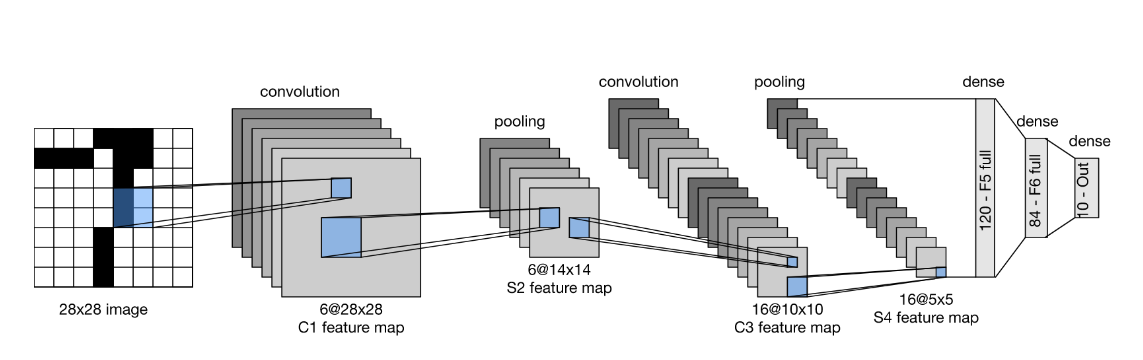

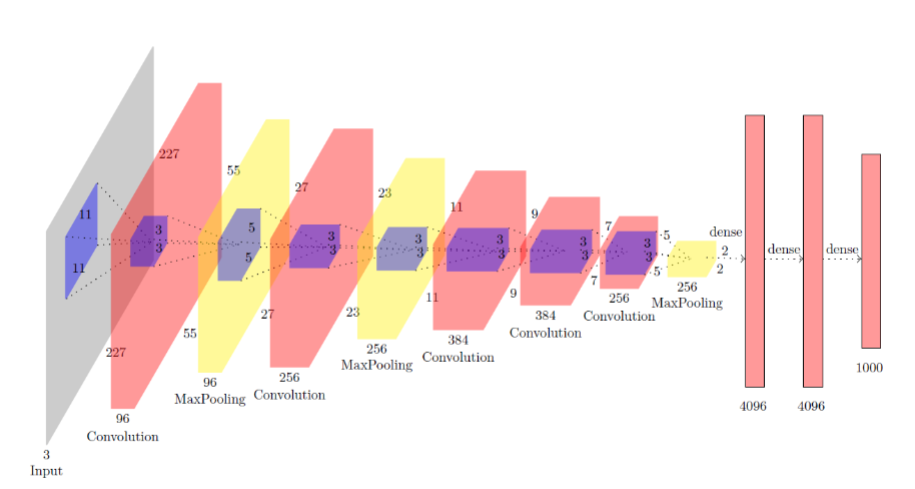

# Train the model

In [ ]:
history = model.fit(x_train, y_train, batch_size=128, epochs=100, validation_split=0.1)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3602 - loss: 1.8184 - val_accuracy: 0.5510 - val_loss: 1.3084
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5821 - loss: 1.2185 - val_accuracy: 0.6378 - val_loss: 1.0895
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6410 - loss: 1.0585 - val_accuracy: 0.6522 - val_loss: 1.0405
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6752 - loss: 0.9625 - val_accuracy: 0.6612 - val_loss: 1.0212
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6941 - loss: 0.9165 - val_accuracy: 0.6462 - val_loss: 1.0518
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7112 - loss: 0.8721 - val_accuracy: 0.6648 - val_loss: 0.9945
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7227 - loss: 0.8397 - val_accuracy: 0.6784 - val_loss: 0.9911
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7321 - loss: 0.8074 - val_acc

# Evaluate the model

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 1.0674618482589722
Test accuracy: 0.7279999852180481


# Plot Accuracy

313/313 - 1s - 2ms/step - accuracy: 0.7280 - loss: 1.0675


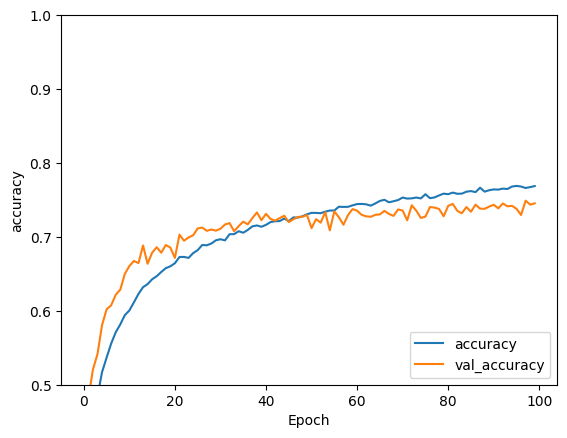

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)